In [7]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

csv_files = glob.glob("combined_data*")

combined_df = \
(
    pd.
    concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
)

combined_df.to_csv("RTH_ETH_combined_data.csv",index=False)

In [8]:
csv_files

['combined_data_ETH.csv', 'combined_data_RTH.csv']

In [3]:
combined_df.head(-5)

,Unnamed: 0,SPX,ES_BID,ES_ASK,VIX
0,2025-04-01 20:15:21.924268,5630.320,5671.50,5672.00,21.77
1,2025-04-01 20:15:24.955344,5630.320,5671.50,5672.00,21.77
2,2025-04-01 20:15:27.986076,5630.695,5672.00,5672.25,21.77
3,2025-04-01 20:15:30.992653,5630.945,5672.25,5672.50,21.77
4,2025-04-01 20:15:34.026633,5631.195,5672.50,5672.75,21.77
...,...,...,...,...,...
169642,2025-04-10 16:14:30.967265,5268.050,5313.00,5313.25,41.00
169643,2025-04-10 16:14:34.005253,5268.050,5314.00,5314.25,40.92
169644,2025-04-10 16:14:37.053558,5268.050,5315.00,5315.50,40.92
169645,2025-04-10 16:14:40.066367,5268.050,5315.50,5315.75,40.92


In [9]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169652 entries, 0 to 169651
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  169652 non-null  object 
 1   SPX         169652 non-null  float64
 2   ES_BID      169652 non-null  float64
 3   ES_ASK      169652 non-null  float64
 4   VIX         162289 non-null  float64
dtypes: float64(4), object(1)
memory usage: 6.5+ MB


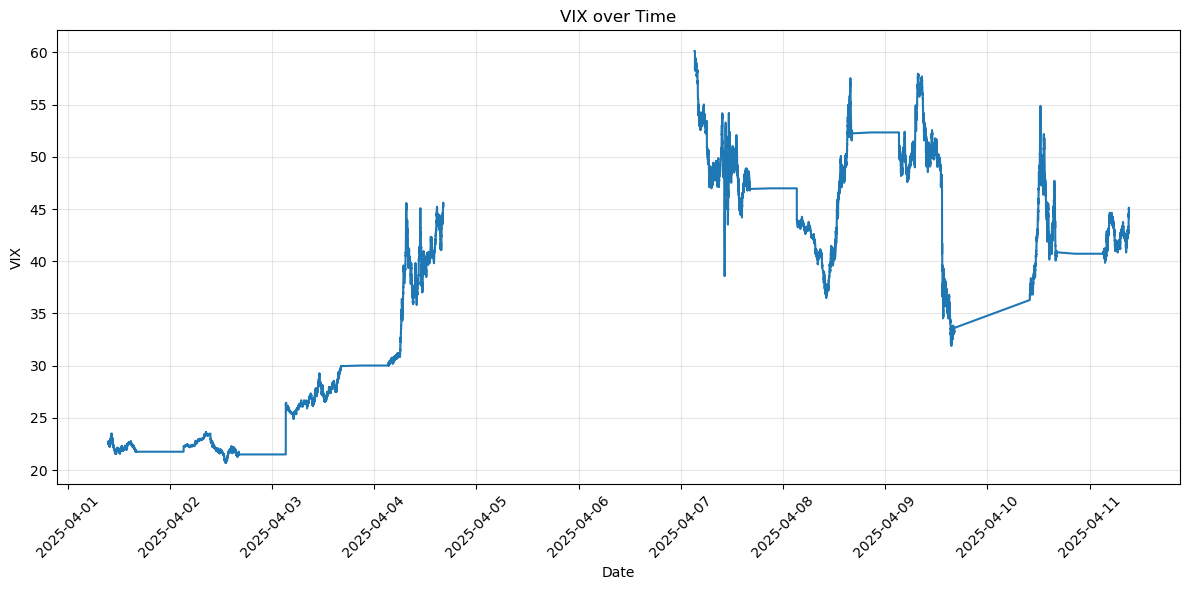

In [10]:
combined_df.iloc[:,0]=\
(
    pd
    .to_datetime(combined_df.iloc[:,0])
)
#Sort by date
combined_df = \
(
    combined_df
    .sort_values(by=combined_df.columns[0])
)

plt.figure(figsize=(12, 6))
plt.plot(combined_df.iloc[:, 0], combined_df['VIX'])
plt.xlabel('Date')
plt.ylabel('VIX')
plt.title('VIX over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

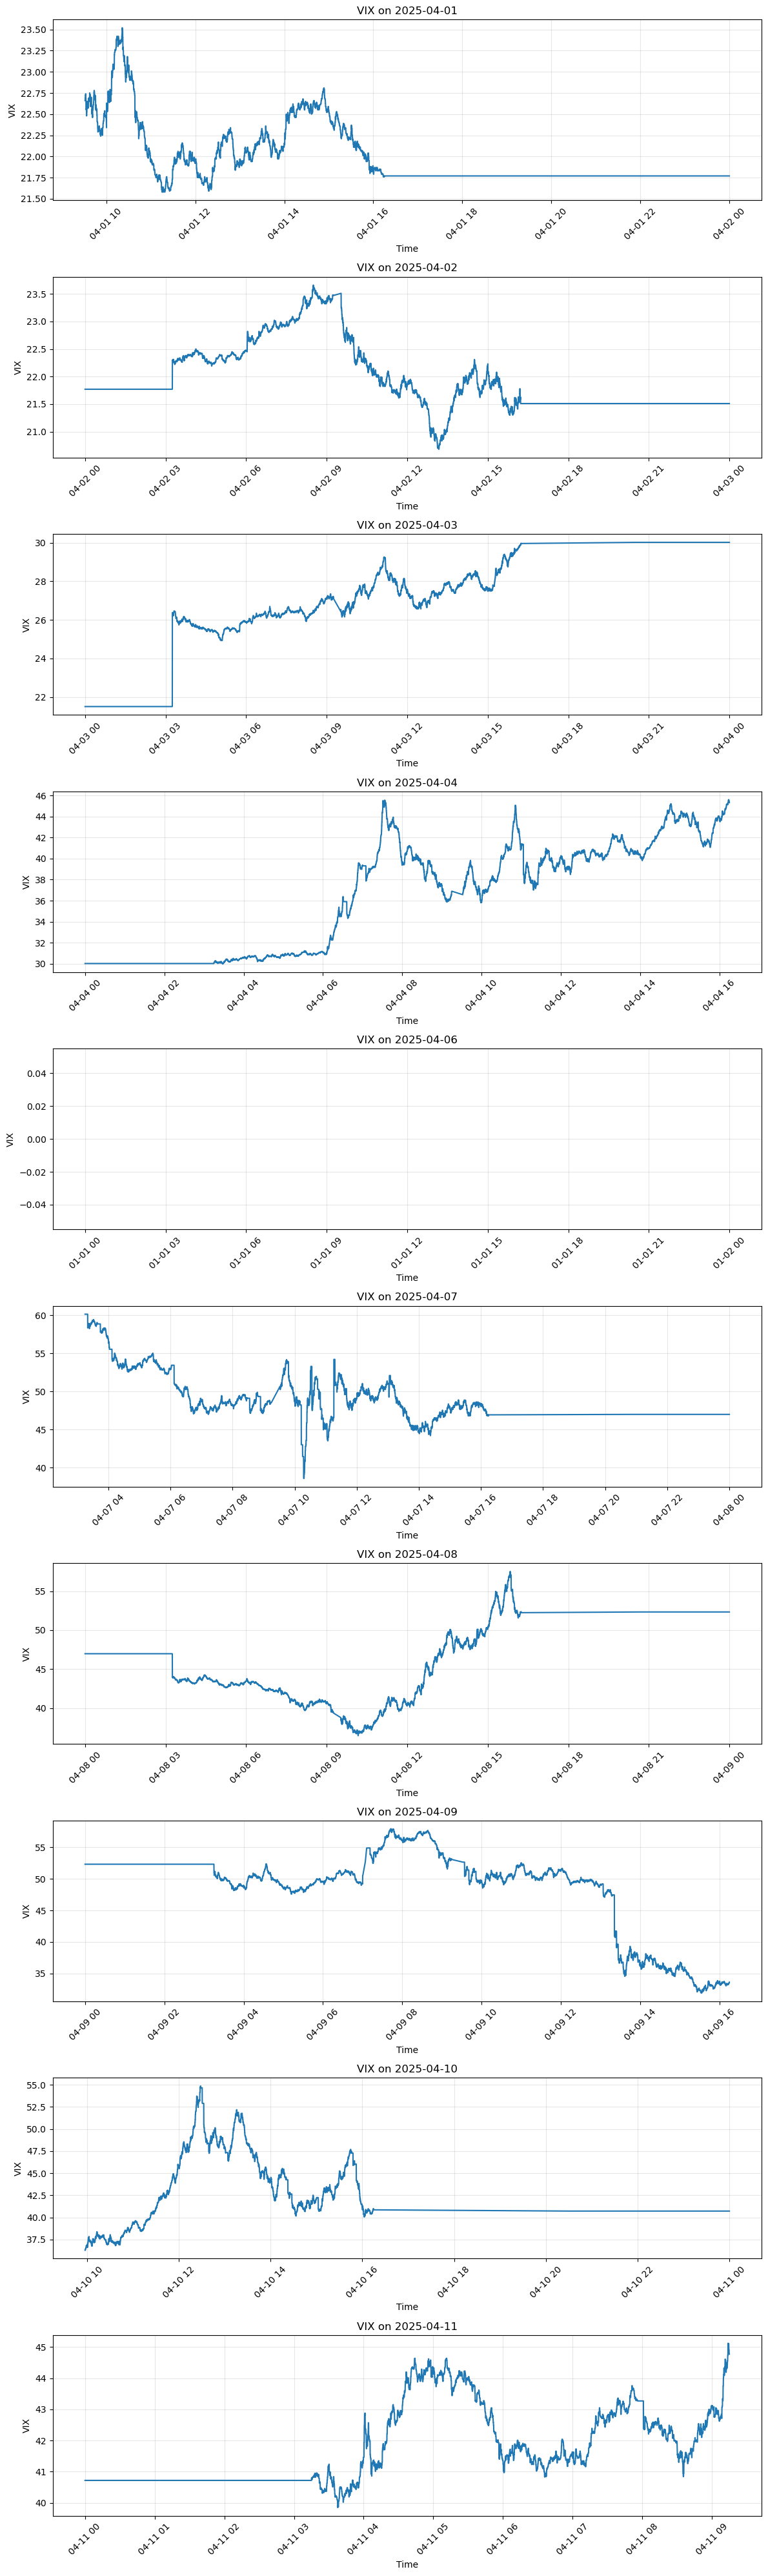

In [18]:
# Convert to datetime
first_col = combined_df.columns[0]
combined_df[first_col] = pd.to_datetime(combined_df[first_col], errors='coerce')

# Extract just the date (without time)
combined_df['date_only'] = combined_df.iloc[:, 0].dt.date

# Get unique dates
unique_dates = sorted(combined_df['date_only'].unique())

# Create subplots
n_dates = len(unique_dates)
fig, axes = plt.subplots(n_dates, 1, figsize=(12, 4*n_dates))

# Handle case where there's only one date
if n_dates == 1:
    axes = [axes]

for i, date in enumerate(unique_dates):
    date_data = combined_df[combined_df['date_only'] == date]
    axes[i].plot(date_data.iloc[:, 0], date_data['VIX'])
    axes[i].set_title(f'VIX on {date}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('VIX')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# Calculate VIX mean and std dev for each day
daily_stats = combined_df.groupby('date_only')['VIX'].agg(['mean', 'std','max','min'])
daily_stats.columns = ['Mean_VIX', 'StdDev_VIX',"Max_Vix","Min_Vix"]

print(daily_stats)

             Mean_VIX  StdDev_VIX  Max_Vix  Min_Vix
date_only                                          
2025-04-01  22.072258    0.389305    23.52    21.58
2025-04-02  22.026768    0.600563    23.66    20.68
2025-04-03  26.673273    2.710433    30.02    21.51
2025-04-04  36.396447    5.227862    45.61    29.99
2025-04-06        NaN         NaN      NaN      NaN
2025-04-07  49.226300    3.262036    60.13    38.58
2025-04-08  45.920294    4.912985    57.52    36.48
2025-04-09  48.542261    6.629675    57.96    31.90
2025-04-10  42.514646    3.686513    54.87    36.29
2025-04-11  41.765235    1.213330    45.12    39.85


In [ ]:
#Plotting SPX against Time
plt.figure(figsize=(12, 6))
plt.plot(combined_df.iloc[:, 0], combined_df['SPX'])
plt.xlabel('Date')
plt.ylabel('SPX')
plt.title('SPX over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
SPX_stats = \
(
    combined_df
    .groupby("date_only")["SPX"]
    .agg(["mean","std","max","min"])
)

SPX_stats.column=['Mean_SPX', 'StdDev_SPX',"Max_SPX","Min_SPX"]

print(SPX_stats)

                   mean         std       max       min
date_only                                              
2025-04-01  5617.325982   17.615055  5650.570  5558.600
2025-04-02  5605.253502   52.534742  5695.140  5482.470
2025-04-03  5454.701058   45.904689  5522.595  5354.895
2025-04-04  5253.294993  100.195396  5392.270  5070.470
2025-04-06  5242.390932   21.908613  5280.770  5181.770
2025-04-07  5143.330102   99.752787  5324.520  4835.160
2025-04-08  5090.429493  104.103902  5267.260  4879.520
2025-04-09  5028.362514  175.363005  5481.230  4837.020
2025-04-10  5243.249150   41.753298  5334.890  5116.230
2025-04-11  5287.523151   24.662420  5344.675  5224.300


C:\Users\chang\AppData\Local\Temp\ipykernel_25264\163405933.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  SPX_stats.column=['Mean_SPX', 'StdDev_SPX',"Max_SPX","Min_SPX"]
